# Camera-pose alignment spike: tie-point correction for the real-WAC overlay

`image_generation.ipynb`'s Phase 6B overlay (the real, ISIS-processed WAC crop mapprojected onto
the basemap) used to be visibly not perfectly aligned with it. That turned out to be mostly a
ground-truth bug, not a camera-pose one: `isis_wac.run_spiceinit` hardcoded `shape=ellipsoid` for
every real-WAC cube, when the fix was attaching ISIS's own real global lunar DEM
(`shape=user`) instead -- see `docs/pose-alignment.md`. That fix now lives in the main
pipeline (every real-WAC cube gets the real DEM by default), so this notebook no longer compares
DEM against ellipsoid -- there's nothing left running through the ellipsoid.

**On the back burner, not superseded** (the user's own framing): the DEM fix
closed the specific gap visible on this candidate, but the capability this notebook exercises --
measuring alignment statistics, independent of whether a correction actually gets applied --
stays valuable. There's no guarantee a future WAC product's initial SPICE-derived registration will
be this clean; this is exactly the tooling that would catch it if not.

**The options being compared, systematically**: every correction below varies along three axes --

- **projection**: `2D->2D` fits a correction directly between two already map-projected rasters
  (`src/trntest/pose_alignment/tie_point_matching.py`, no camera model involved at all) vs. `3D->2D`
  fits a correction to the actual camera pose, projecting a real 3D ground point through it to a 2D
  image pixel (`src/trntest/pose_alignment/wac_camera_model.py` + `control_network.py`, real ISIS
  control points).
- **matcher**: `SIFT` (classical, Sobel-filtered) vs. `LightGlue` (learned DISK features + learned
  matcher -- more matches, headroom for future low-texture EDRs SIFT might struggle on).
- **correction**: `uncorrected` (the raw match-implied offset, no fit at all) through increasingly
  flexible 2D models (`similarity` 4 DOF, `affine` 6 DOF, `homography` 8 DOF) to the one physically
  real correction, `6-DOF pose` (a camera exterior-orientation correction, fit against real
  ISIS control points, then baked back into the crop cube so ISIS's own unmodified `cam2map`
  reprojects it).

This notebook evaluates the same combinations of these three axes the original investigation did,
plus SIFT's own 3D->2D pair (rows 5-6) added afterward specifically to test a real, still-open
question the table itself raised (see the results table's own markdown for the full trail) --
reported as one table (`results_df` below) instead of scattered prints, with each blink overlay
labeled by which table row it corresponds to. **Expect the overlays to look similarly well-aligned
and a bit boring now** -- that's the DEM fix working, not a wasted notebook; a clean before/after
here is itself useful confirmation, not just a null result.

In [1]:
import warnings

import numpy as np
import pandas as pd
import rasterio
from scipy.spatial.transform import Rotation

import trntest
from trntest import isis_campt, isis_wac, plotting, tie_points
from trntest.pose_alignment import control_network, tie_point_matching, wac_camera_model

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()
dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
# NOT dataset.populate(limit=1) -- if entry 0 is already populated (e.g. from image_generation.ipynb),
# populate(limit=1) silently advances to the next *undone* entry instead and does real, unwanted work
# there (confirmed live -- see old_notebooks/reproject_spike.py's own identical fix). This notebook
# only ever touches entry.crop_result/entry.dem_ortho_result/entry.camera, all self-healing
# TrnTestEntry properties -- no populate() call needed at all.
entry = dataset[0]

# `entry.crop_result` carries ISIS's real global lunar DEM by default now (isis_wac.run_spiceinit) --
# no separate DEM-attachment step needed here anymore, unlike this notebook's earlier form.
wac_path = isis_wac.run_cam2map_for_crop(entry.crop_result, entry.dem_ortho_result, entry.per_image_config)
basemap_path = entry.dem_ortho_result.ortho
print("WAC mapprojected crop (DEM shape model):", wac_path)
print("Basemap ortho:", basemap_path)

results = []  # one dict per table row, appended right after each metric is computed below

WAC mapprojected crop (DEM shape model): /workspace/output/trn_dataset/_work/M1327210646CE/crop/M1327210646CE.vis.cal.stitched.crop-cam2map.tif
Basemap ortho: /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke_atc_realparams_normaltilt_wacemp.tif


## Crop the basemap to the WAC's own footprint, and prepare both for matching

The basemap ortho covers a much larger area than the WAC crop's own footprint -- cropping to
match (`tie_point_matching.crop_to_footprint`, padded 15%) gives the feature matcher a far smaller,
more relevant search space; confirmed empirically to matter for match quality, not just compute.

Both `wac_path` and the basemap ortho are on the same ~100 m/px working grid (`config.
DEFAULT_DEM_TARGET_GSD_M`) -- but that's genuinely native resolution for the basemap
(`luna_wac_global`'s own ~100 m/px mosaic) and *not* for this WAC crop: `isis_wac.
run_cam2map_for_crop`'s `PIXRES=map` forces its output onto that same 100 m/px grid regardless of
the camera's own real resolution at this pose, which a direct `cam2map PIXRES=camera` probe found
to be ~184 m/px for this candidate (~1.8x coarser). Matching
SIFT keypoints on the interpolated-not-actually-resolved 100 m/px grid risks treating resampling
texture as real structure. `tie_point_matching.native_wac_gsd_m` estimates the WAC crop's native
GSD from the camera's own already-computed ground geometry (no extra ISIS call), and
`downsample_to_gsd` (area-averaging) brings both rasters down to that scale before matching.
`to_uint8_for_matching` then converts each to 8-bit, stretching over valid pixels only.

In [2]:
basemap_cropped_path = tie_point_matching.crop_to_footprint(
    basemap_path, wac_path, entry.per_image_config.output_dir / "alignment" / "basemap_cropped.tif"
)

target_gsd_m = tie_point_matching.native_wac_gsd_m(entry.camera)
print(f"Downsampling to the WAC crop's estimated native resolution: {target_gsd_m:.0f} m/px")
wac_matching_path = tie_point_matching.downsample_to_gsd(
    wac_path, target_gsd_m, entry.per_image_config.output_dir / "alignment" / "wac_matching_res.tif"
)
basemap_matching_path = tie_point_matching.downsample_to_gsd(
    basemap_cropped_path, target_gsd_m, entry.per_image_config.output_dir / "alignment" / "basemap_matching_res.tif"
)

wac_image, wac_valid = tie_point_matching.to_uint8_for_matching(wac_matching_path)
basemap_image, basemap_valid = tie_point_matching.to_uint8_for_matching(basemap_matching_path)
print(f"WAC: {wac_image.shape}, valid {wac_valid.mean():.1%}")
print(f"Basemap: {basemap_image.shape}, valid {basemap_valid.mean():.1%}")

Downsampling to the WAC crop's estimated native resolution: 211 m/px


WAC: (865, 799), valid 71.7%
Basemap: (985, 985), valid 100.0%


## Feature matching: SIFT

SIFT on Sobel-filtered versions of each image (see `tie_point_matching.match_features`'s docstring for
why: raw-intensity matching across two different sensors/processing pipelines is far less reliable
than matching on edge/gradient content), with a mutual ratio test and two RANSAC geometric-
consistency passes (homography, then epipolar).

In [3]:
basemap_points_px, wac_points_px = tie_point_matching.match_features(basemap_image, basemap_valid, wac_image, wac_valid)
print(f"{len(basemap_points_px)} matched points survived ratio/symmetry/RANSAC verification")

with rasterio.open(basemap_matching_path) as src:
    basemap_transform = src.transform
with rasterio.open(wac_matching_path) as src:
    wac_transform = src.transform

basemap_points_map = tie_point_matching.pixel_points_to_map(basemap_points_px, basemap_transform)
wac_points_map = tie_point_matching.pixel_points_to_map(wac_points_px, wac_transform)

435 matched points survived ratio/symmetry/RANSAC verification


**Table row 1: 2D->2D, SIFT, uncorrected.** The raw match-implied offset -- no fit at all -- lets
us see how bad an uncorrected match set looks before any correction is applied.

In [4]:
raw_offsets_m = wac_points_map - basemap_points_map
raw_distances_m = np.linalg.norm(raw_offsets_m, axis=1)
print(f"Raw offset distance: mean {raw_distances_m.mean():.0f}m, std {raw_distances_m.std():.0f}m")
print(f"Range: {raw_distances_m.min():.0f}m - {raw_distances_m.max():.0f}m")

results.append(
    {
        "row": 1,
        "projection": "2D->2D",
        "matcher": "SIFT",
        "correction": "uncorrected",
        "dof": 0,
        "n_points": len(raw_distances_m),
        "n_kept": len(raw_distances_m),
        "residual_mean_m": raw_distances_m.mean(),
        "residual_max_m": raw_distances_m.max(),
        "residual_mean_px": raw_distances_m.mean() / target_gsd_m,
    }
)

Raw offset distance: mean 181m, std 86m
Range: 12m - 535m


## Fit the 2D correction: similarity, full affine, and homography (SIFT matches)

`fit_similarity_correction` (translation + rotation + uniform scale, 4 DOF), `fit_affine_correction`
(adds independent x/y scale and shear, 6 DOF), and `fit_homography_correction` (full projective,
8 DOF) -- none asserted as physically "correct" (a real camera pose error has 6 DOF before even
accounting for this being a pushframe sensor's extended-exposure capture, and the mapping from that
onto a 2D map-space distortion isn't one-to-one), fit from the *same* match set for a direct,
apples-to-apples comparison. **Table rows 2-4.**

In [5]:
correction_similarity, inliers_similarity, residuals_similarity_m = tie_point_matching.fit_similarity_correction(
    wac_points_map, basemap_points_map
)
correction_affine, inliers_affine, residuals_affine_m = tie_point_matching.fit_affine_correction(
    wac_points_map, basemap_points_map
)
homography, inliers_homography, residuals_homography_m = tie_point_matching.fit_homography_correction(
    wac_points_map, basemap_points_map
)

for row, name, dof, inliers, residuals_m in [
    (2, "similarity", 4, inliers_similarity, residuals_similarity_m),
    (3, "affine", 6, inliers_affine, residuals_affine_m),
    (4, "homography", 8, inliers_homography, residuals_homography_m),
]:
    inlier_residuals_m = residuals_m[inliers]
    print(
        f"{name:12s} ({dof} DOF)  inliers {inliers.sum():3d}/{len(inliers)}   "
        f"residual mean {inlier_residuals_m.mean():5.0f}m ({inlier_residuals_m.mean() / target_gsd_m:.2f}px)   "
        f"max {inlier_residuals_m.max():5.0f}m ({inlier_residuals_m.max() / target_gsd_m:.2f}px)"
    )
    results.append(
        {
            "row": row,
            "projection": "2D->2D",
            "matcher": "SIFT",
            "correction": name,
            "dof": dof,
            "n_points": len(inliers),
            "n_kept": int(inliers.sum()),
            "residual_mean_m": inlier_residuals_m.mean(),
            "residual_max_m": inlier_residuals_m.max(),
            "residual_mean_px": inlier_residuals_m.mean() / target_gsd_m,
        }
    )

scale = np.sqrt(correction_similarity.a**2 + correction_similarity.d**2)
rotation_deg = np.degrees(np.arctan2(correction_similarity.d, correction_similarity.a))
print(
    f"\nSimilarity fit: scale {scale:.4f}  rotation {rotation_deg:.3f} deg  "
    f"translation ({correction_similarity.c:.1f}, {correction_similarity.f:.1f}) m"
)

similarity   (4 DOF)  inliers 412/435   residual mean    97m (0.46px)   max   333m (1.58px)
affine       (6 DOF)  inliers 413/435   residual mean    97m (0.46px)   max   338m (1.60px)
homography   (8 DOF)  inliers 418/435   residual mean   103m (0.49px)   max   294m (1.39px)

Similarity fit: scale 0.9999  rotation 0.014 deg  translation (70.3, -133.2) m


## Apply each 2D correction and compare via the existing blink overlay

`apply_correction` composes an `affine.Affine` fit (similarity or full affine) with the WAC
raster's own georeferencing and resamples back onto its original grid; `apply_homography_correction`
does the projective equivalent. All three corrected rasters drop straight into the *existing*
`plotting.plot_overlay_toggle` blink comparator with no further plumbing changes.

In [6]:
alignment_dir = entry.per_image_config.output_dir / "alignment"
corrected_similarity_path = tie_point_matching.apply_correction(
    wac_path, correction_similarity, alignment_dir / "wac_corrected_similarity.tif"
)
corrected_affine_path = tie_point_matching.apply_correction(
    wac_path, correction_affine, alignment_dir / "wac_corrected_affine.tif"
)
corrected_homography_path = tie_point_matching.apply_homography_correction(
    wac_path, homography, alignment_dir / "wac_corrected_homography.tif"
)

**Table rows 1 and 6** (uncorrected, 2D->2D and 3D->2D respectively) both describe this same
uncorrected raster -- shown once here.


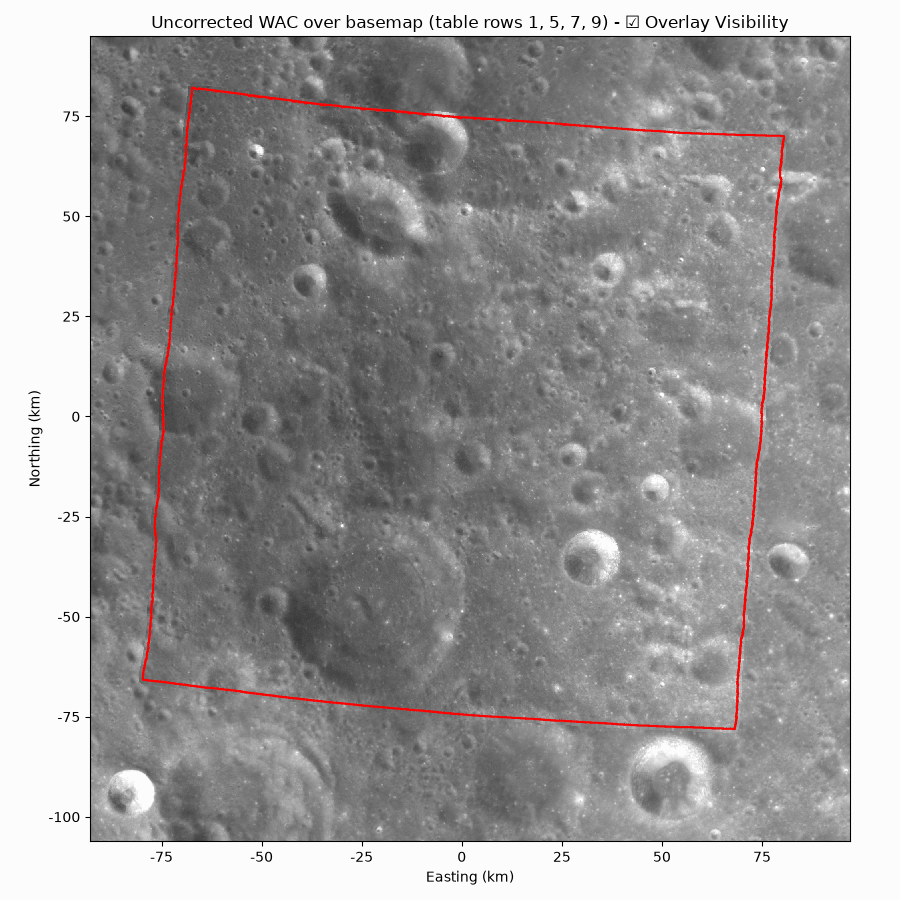

In [7]:
plotting.plot_overlay_toggle(basemap_path, wac_path, title="Uncorrected WAC over basemap (table rows 1, 5, 7, 9)")


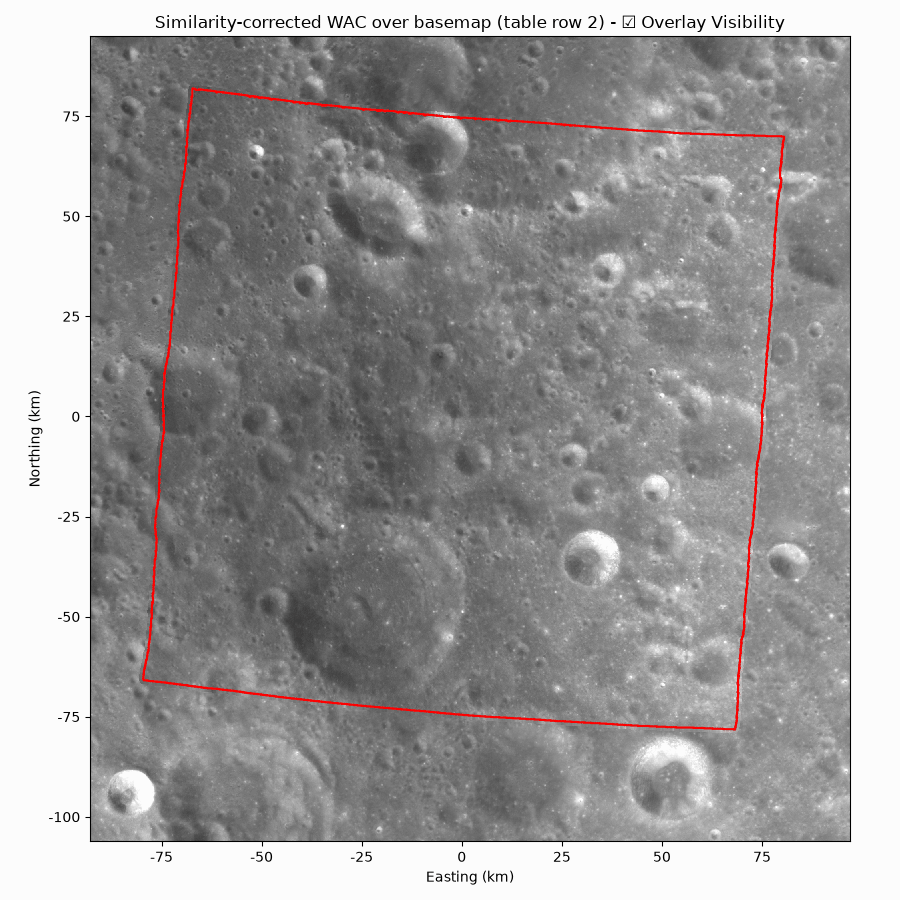

In [8]:
plotting.plot_overlay_toggle(
    basemap_path, corrected_similarity_path, title="Similarity-corrected WAC over basemap (table row 2)"
)


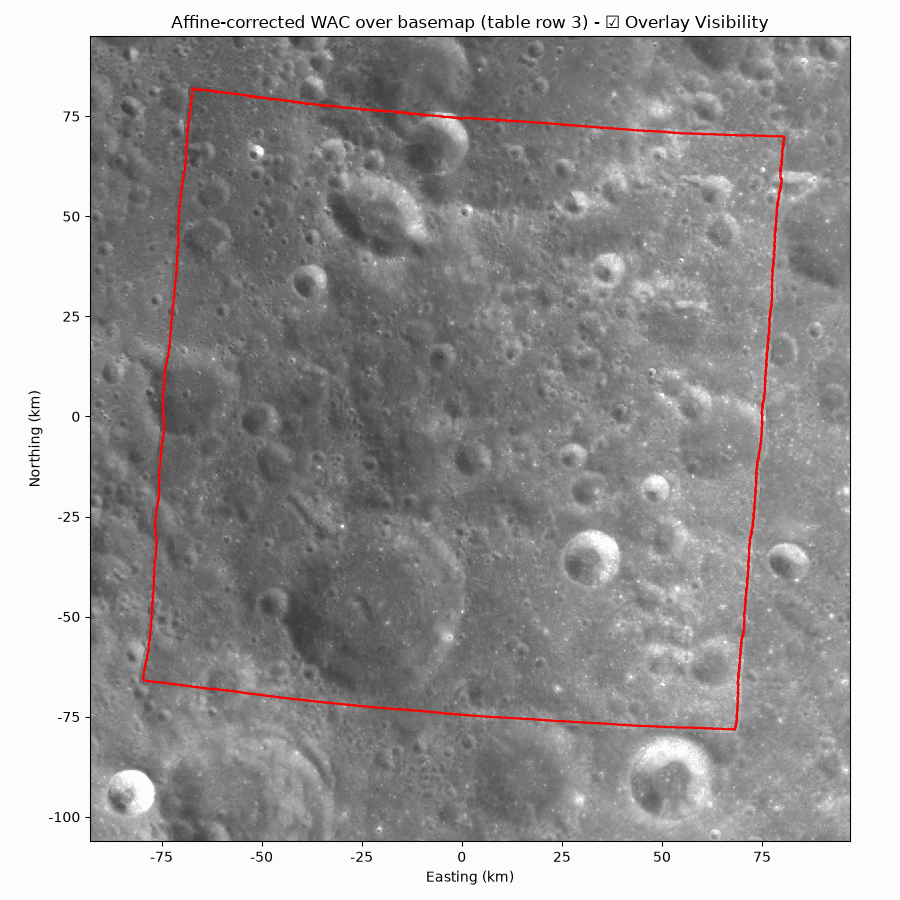

In [9]:
plotting.plot_overlay_toggle(
    basemap_path, corrected_affine_path, title="Affine-corrected WAC over basemap (table row 3)"
)


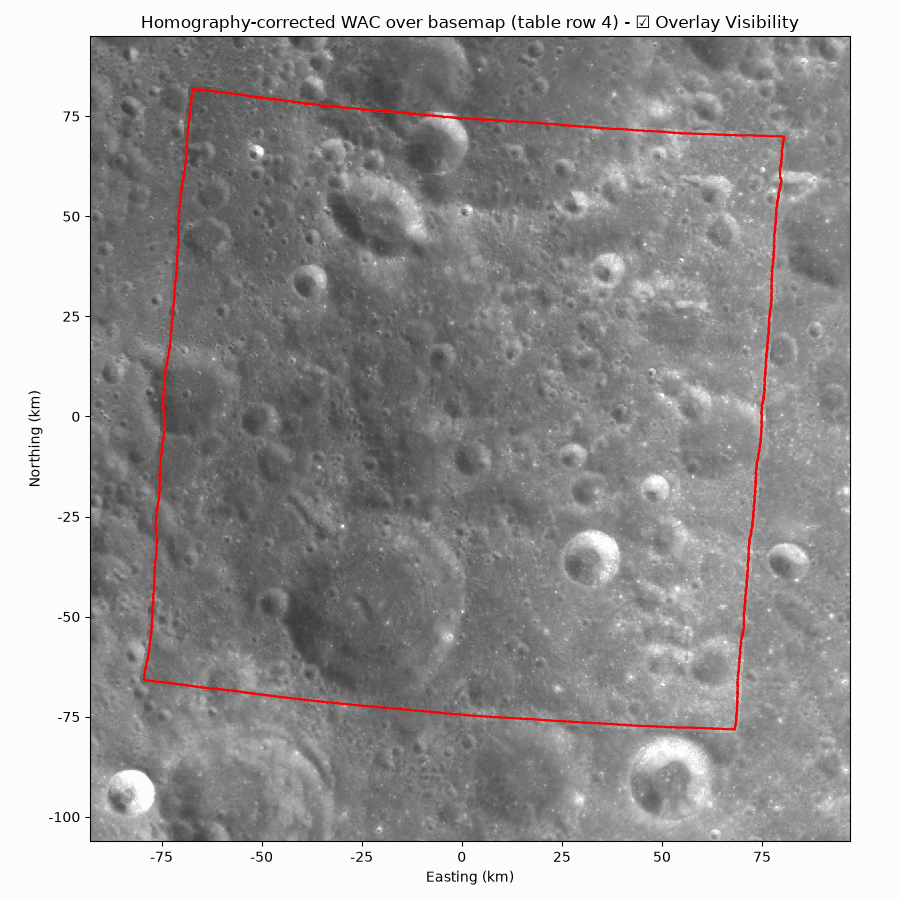

In [10]:
plotting.plot_overlay_toggle(
    basemap_path, corrected_homography_path, title="Homography-corrected WAC over basemap (table row 4)"
)

## The 3D->2D approach: real ISIS control points, a real camera-pose correction

Everything above corrects the WAC raster's own map-space georeferencing after the fact -- a 2D fix,
not a camera-pose one. `control_network.resolve_control_points` converts a matched-point set into
real ISIS control points: for each match, the real image-space pixel it was observed at in the
*original*, pre-`cam2map` WAC crop cube, resolved through whatever camera model `entry.crop_result`
actually carries (ISIS's real DEM, by default, now) -- `isis_campt.resolve_ground_to_image_model`
picks the right authority (native ISIS Pushframe model, not CSM -- see its own docstring for why).
The trusted ground truth (`ground_lonlat`) comes from the basemap's own georeferencing at each
match, `(lon, lat)` only, no elevation baked in yet -- `isis_wac.sample_lunar_dem_radii_batch`
samples elevation from *the same* real DEM the camera model above resolved through (deliberately
camera-independent: a basemap point has no reason to be visible to *this* one camera's own view for
its elevation to be meaningful) -- see `control_network.py`'s own module docstring for why mixing
an elevation-aware ground truth with an elevation-unaware camera model (or vice versa) would
conflate real camera-pose error with a shape-model mismatch.

`wac_camera_model.py`'s hand-rolled forward projection stands in for `jigsaw`, which hit a
root-caused, unfixable bug in its PushFrame framelet search (see `docs/pose-alignment.md`
for the full trail). Its optics chain is validated to exact (0.000px) agreement with real `campt`
output, and its framelet search is validated to 0.00m ground error round-tripped through `campt`'s
trusted inverse. `n_framelets`/`et0`/`et_per_line` are pure camera-timing calibration -- independent
of which matcher's points get fed through it, so computed once and reused for both matchers' 3D rows
below (`resolve_3d_control_points`/`fit_and_report_pose_correction` factor out the rest of the
shared pipeline the same way, rather than duplicating it per matcher).

In [11]:
ground_to_image_model = isis_campt.resolve_ground_to_image_model(
    entry.stitched, entry.crop_result, entry.per_image_config
)
with rasterio.open(wac_path) as src:
    map_crs = src.crs

with warnings.catch_warnings():
    # NotGeoreferencedWarning is expected for an ISIS .cub at this pipeline stage (no geotransform
    # yet, not a bug) -- see plotting.read_raster_band's own docstring for this same suppression.
    warnings.simplefilter("ignore", rasterio.errors.NotGeoreferencedWarning)
    with rasterio.open(entry.crop_result.cub_path) as src:
        n_lines = src.height
n_framelets = n_lines // wac_camera_model.FRAMELET_HEIGHT
et0, et_per_line = wac_camera_model.calibrate_et_per_crop_line(entry.crop_result.cub_path, n_lines)
print(f"crop: {n_framelets} framelets, et0={et0:.3f}, et_per_line={et_per_line:.6f}")


def ground_space_residual_m(cub_path, observed_pixels, ground_points_me_m):
    """The one legitimate ground-space residual for a set of already-resolved `observed_pixels`:
    queries `campt` (via `isis_campt.image_to_ground_points_batch`) for the ground point each
    pixel actually corresponds to under `cub_path`'s own real camera model, and compares that
    directly (in meters, body-fixed) against the trusted `ground_points_me_m`. Deliberately avoids
    `wac_camera_model`'s own forward-projection/framelet-search tie-break entirely -- comparing
    predicted-vs-observed *pixels* re-litigates which of several equally-valid framelets is "right"
    whenever a ground point sits in an overlap band (~29% of framelet height, confirmed live -- see
    `wac_camera_model.find_framelet_and_project`'s own docstring), which has no principled answer.
    This function never searches for a framelet: `observed_pixels` are already fixed coordinates,
    and one pixel has exactly one ground point -- nothing to litigate."""
    ground_points = isis_campt.image_to_ground_points_batch(cub_path, observed_pixels)
    errors_m = []
    for ground_point, trusted_me_m in zip(ground_points, ground_points_me_m, strict=True):
        if ground_point is None:
            continue
        lon_deg, lat_deg, radius_m = ground_point
        observed_me_m = np.array(tie_points.lonlat_to_ground_km(lon_deg, lat_deg, radius_m / 1000.0)) * 1000.0
        errors_m.append(np.linalg.norm(observed_me_m - trusted_me_m))
    return np.array(errors_m)


def resolve_3d_control_points(wac_points_map, basemap_points_map, matcher_label):
    """Shared by every matcher's 3D rows below: resolve_control_points, DEM-consistent ground truth,
    and the baseline (uncorrected) residual, both ways -- identical steps regardless of which
    matcher's points come in. Reports both the pixel-space residual (via `wac_camera_model`'s own
    forward projection -- kept for cross-checking the fit's own optimization target, but subject to
    the framelet-overlap ambiguity `ground_space_residual_m`'s docstring explains) and the legitimate
    ground-space one (the one actually used in `results_df` below)."""
    observed_pixels, ground_lonlat = control_network.resolve_control_points(
        wac_points_map, basemap_points_map, map_crs, ground_to_image_model, entry.per_image_config
    )
    print(
        f"{len(observed_pixels)} real ISIS control points resolved (from {len(wac_points_map)} {matcher_label} matches)"
    )
    dem_radii_m = isis_wac.sample_lunar_dem_radii_batch(ground_lonlat, entry.per_image_config)
    print(
        f"Sampled DEM radii: min {dem_radii_m.min():.0f}m, max {dem_radii_m.max():.0f}m, "
        f"mean {dem_radii_m.mean():.0f}m, std {dem_radii_m.std():.0f}m "
        f"(real, varying terrain, not a flat ellipsoid constant -- confirms the DEM is actually in effect)"
    )
    ground_points_me_m = (
        np.array(
            [
                tie_points.lonlat_to_ground_km(lon_deg, lat_deg, radius_m / 1000.0)
                for (lon_deg, lat_deg), radius_m in zip(ground_lonlat, dem_radii_m, strict=True)
            ]
        )
        * 1000.0
    )
    baseline_residuals_px = []
    for ground_pt, obs in zip(ground_points_me_m, observed_pixels, strict=True):
        predicted = wac_camera_model.find_framelet_and_project(ground_pt, n_framelets, et0, et_per_line)
        if predicted is not None:
            baseline_residuals_px.append((predicted[0] - obs[0], predicted[1] - obs[1]))
    baseline_residuals_px = np.array(baseline_residuals_px)
    baseline_norms = np.linalg.norm(baseline_residuals_px, axis=1)
    print(
        f"Baseline (uncorrected), pixel-space (framelet-tiebreak-sensitive): "
        f"{len(baseline_residuals_px)}/{len(observed_pixels)} points resolved, "
        f"residual mean {baseline_norms.mean():.2f}px, max {baseline_norms.max():.2f}px"
    )
    baseline_ground_errors_m = ground_space_residual_m(entry.crop_result.cub_path, observed_pixels, ground_points_me_m)
    print(
        f"Baseline (uncorrected), ground-space (no ambiguity): "
        f"{len(baseline_ground_errors_m)}/{len(observed_pixels)} points resolved, "
        f"residual mean {baseline_ground_errors_m.mean():.1f}m, max {baseline_ground_errors_m.max():.1f}m"
    )
    return observed_pixels, ground_points_me_m, baseline_norms, baseline_ground_errors_m


def fit_and_report_pose_correction(ground_points_me_m, observed_pixels):
    """Shared by every matcher's 3D rows below: `fit_pose_correction`, its own reporting, and the
    legitimate ground-space residual for the *fitted* pose -- bakes the fit's correction into a
    corrected crop copy (`isis_wac.apply_pose_correction_to_crop`) and re-queries `observed_pixels`'
    real ground points through *that* (real ISIS work, not `wac_camera_model`'s own prediction), for
    the same ambiguity-free reason `ground_space_residual_m` exists."""
    fit = wac_camera_model.fit_pose_correction(ground_points_me_m, observed_pixels, n_framelets, et0, et_per_line)
    fit_norms = np.linalg.norm(fit.residuals_px, axis=1)
    # A control point that lands outside crop coverage under the fitted correction gets a fixed, large
    # penalty residual (see fit_pose_correction's own docstring) -- filtered out here for the mean/max
    # stats below since it's a sentinel, not a real pixel error; reported separately if it happens.
    RESOLVED_RESIDUAL_THRESHOLD_PX = 100.0  # well below _UNRESOLVED_RESIDUAL_PX, well above any real fit
    resolved = fit_norms < RESOLVED_RESIDUAL_THRESHOLD_PX
    print(f"Fit success: {fit.success}")
    print(f"delta_position_m (MOON_ME): {fit.correction.delta_position_m}")
    rotvec_deg = np.degrees(Rotation.from_matrix(fit.correction.delta_rotation).as_rotvec())
    print(f"delta_rotation (deg, camera-frame rotation vector): {rotvec_deg}")
    print(
        f"Fitted, pixel-space (framelet-tiebreak-sensitive): {resolved.sum()}/{len(observed_pixels)} points "
        f"resolved, residual mean {fit_norms[resolved].mean():.2f}px, max {fit_norms[resolved].max():.2f}px"
    )
    if not resolved.all():
        print(f"Note: {(~resolved).sum()} control point(s) unresolved at the fitted correction")

    corrected_crop = isis_wac.apply_pose_correction_to_crop(entry.crop_result, fit.correction, entry.per_image_config)
    fitted_ground_errors_m = ground_space_residual_m(corrected_crop.cub_path, observed_pixels, ground_points_me_m)
    print(
        f"Fitted, ground-space (no ambiguity): {len(fitted_ground_errors_m)}/{len(observed_pixels)} points "
        f"resolved, residual mean {fitted_ground_errors_m.mean():.1f}m, max {fitted_ground_errors_m.max():.1f}m"
    )
    return fit, fit_norms, resolved, corrected_crop, fitted_ground_errors_m

crop: 70 framelets, et0=625843678.222, et_per_line=-0.100446


**Table rows 5-6: 3D->2D, SIFT.** Added after the fact, specifically to test a question the
results table below raises: LightGlue's 3D rows (9-10, further down) run a noticeably higher
residual than the 2D rows do, and the leading explanation is that `resolve_control_points` does no
outlier rejection of its own, so LightGlue's noisier raw match set (see row 7) pollutes the 3D
control points more than any 2D row's own RANSAC-cleaned result. **If that explanation is right,
SIFT's already-more-heavily-filtered matches (`match_features`'s own two RANSAC passes), fed through
this exact same 3D pipeline, should land much closer to SIFT's own 2D rows (1-4) than LightGlue's 3D
rows (9-10) do.** See `results_df` below for whether that held up.

In [12]:
observed_pixels_sift, ground_points_sift_me_m, baseline_norms_sift, baseline_ground_errors_sift_m = (
    resolve_3d_control_points(wac_points_map, basemap_points_map, "SIFT")
)

results.append(
    {
        "row": 5,
        "projection": "3D->2D",
        "matcher": "SIFT",
        "correction": "uncorrected",
        "dof": 0,
        "n_points": len(observed_pixels_sift),
        "n_kept": len(baseline_ground_errors_sift_m),
        "residual_mean_m": baseline_ground_errors_sift_m.mean(),
        "residual_max_m": baseline_ground_errors_sift_m.max(),
        "residual_mean_px": baseline_norms_sift.mean(),
    }
)

435 real ISIS control points resolved (from 435 SIFT matches)


Sampled DEM radii: min 1737204m, max 1741872m, mean 1739445m, std 762m (real, varying terrain, not a flat ellipsoid constant -- confirms the DEM is actually in effect)


Baseline (uncorrected), pixel-space (framelet-tiebreak-sensitive): 435/435 points resolved, residual mean 1.12px, max 5.07px


Baseline (uncorrected), ground-space (no ambiguity): 435/435 points resolved, residual mean 184.2m, max 541.2m


In [13]:
fit_sift, fit_norms_sift, resolved_sift, corrected_crop_sift, fitted_ground_errors_sift_m = (
    fit_and_report_pose_correction(ground_points_sift_me_m, observed_pixels_sift)
)

results.append(
    {
        "row": 6,
        "projection": "3D->2D",
        "matcher": "SIFT",
        "correction": "6-DOF pose",
        "dof": 6,
        "n_points": len(observed_pixels_sift),
        "n_kept": len(fitted_ground_errors_sift_m),
        "residual_mean_m": fitted_ground_errors_sift_m.mean(),
        "residual_max_m": fitted_ground_errors_sift_m.max(),
        "residual_mean_px": fit_norms_sift[resolved_sift].mean(),
    }
)

Fit success: True
delta_position_m (MOON_ME): [ -1.3953362  -12.15154544  -0.92638882]
delta_rotation (deg, camera-frame rotation vector): [-0.02783933 -0.0605338  -0.0302762 ]
Fitted, pixel-space (framelet-tiebreak-sensitive): 435/435 points resolved, residual mean 0.62px, max 4.55px


Fitted, ground-space (no ambiguity): 435/435 points resolved, residual mean 112.1m, max 529.6m


## A second matcher: LightGlue

`tie_point_matching.match_features_lightglue` swaps classical SIFT for a deep-learned local-feature
extractor (DISK) + learned matcher -- headroom for future shadowed/low-texture EDRs SIFT might
not find enough points on at all. Same inputs as SIFT above -- only the matcher differs, for a
direct, apples-to-apples comparison against SIFT's own rows. **Table row 7** is the raw
match-implied offset (same role as row 1). **Table row 8** is the same match set's homography fit
(the model already validated by direct user visual inspection as giving a real, non-noise
improvement).

In [14]:
basemap_points_px_lg, wac_points_px_lg = tie_point_matching.match_features_lightglue(
    basemap_image, basemap_valid, wac_image, wac_valid
)
print(f"SIFT:      {len(basemap_points_px)} matched points")
print(f"LightGlue: {len(basemap_points_px_lg)} matched points")

basemap_points_map_lg = tie_point_matching.pixel_points_to_map(basemap_points_px_lg, basemap_transform)
wac_points_map_lg = tie_point_matching.pixel_points_to_map(wac_points_px_lg, wac_transform)

raw_offsets_lg_m = wac_points_map_lg - basemap_points_map_lg
raw_distances_lg_m = np.linalg.norm(raw_offsets_lg_m, axis=1)
print(f"LightGlue raw offset: mean {raw_distances_lg_m.mean():.0f}m, std {raw_distances_lg_m.std():.0f}m")

results.append(
    {
        "row": 7,
        "projection": "2D->2D",
        "matcher": "LightGlue",
        "correction": "uncorrected",
        "dof": 0,
        "n_points": len(raw_distances_lg_m),
        "n_kept": len(raw_distances_lg_m),
        "residual_mean_m": raw_distances_lg_m.mean(),
        "residual_max_m": raw_distances_lg_m.max(),
        "residual_mean_px": raw_distances_lg_m.mean() / target_gsd_m,
    }
)

homography_lg, inliers_homography_lg, residuals_homography_lg_m = tie_point_matching.fit_homography_correction(
    wac_points_map_lg, basemap_points_map_lg
)
inlier_residuals_lg_m = residuals_homography_lg_m[inliers_homography_lg]
print(
    f"LightGlue homography: inliers {inliers_homography_lg.sum():3d}/{len(inliers_homography_lg)}   "
    f"residual mean {inlier_residuals_lg_m.mean():5.0f}m ({inlier_residuals_lg_m.mean() / target_gsd_m:.2f}px)"
)

results.append(
    {
        "row": 8,
        "projection": "2D->2D",
        "matcher": "LightGlue",
        "correction": "homography",
        "dof": 8,
        "n_points": len(inliers_homography_lg),
        "n_kept": int(inliers_homography_lg.sum()),
        "residual_mean_m": inlier_residuals_lg_m.mean(),
        "residual_max_m": inlier_residuals_lg_m.max(),
        "residual_mean_px": inlier_residuals_lg_m.mean() / target_gsd_m,
    }
)

SIFT:      435 matched points
LightGlue: 764 matched points
LightGlue raw offset: mean 275m, std 565m
LightGlue homography: inliers 699/764   residual mean   143m (0.68px)



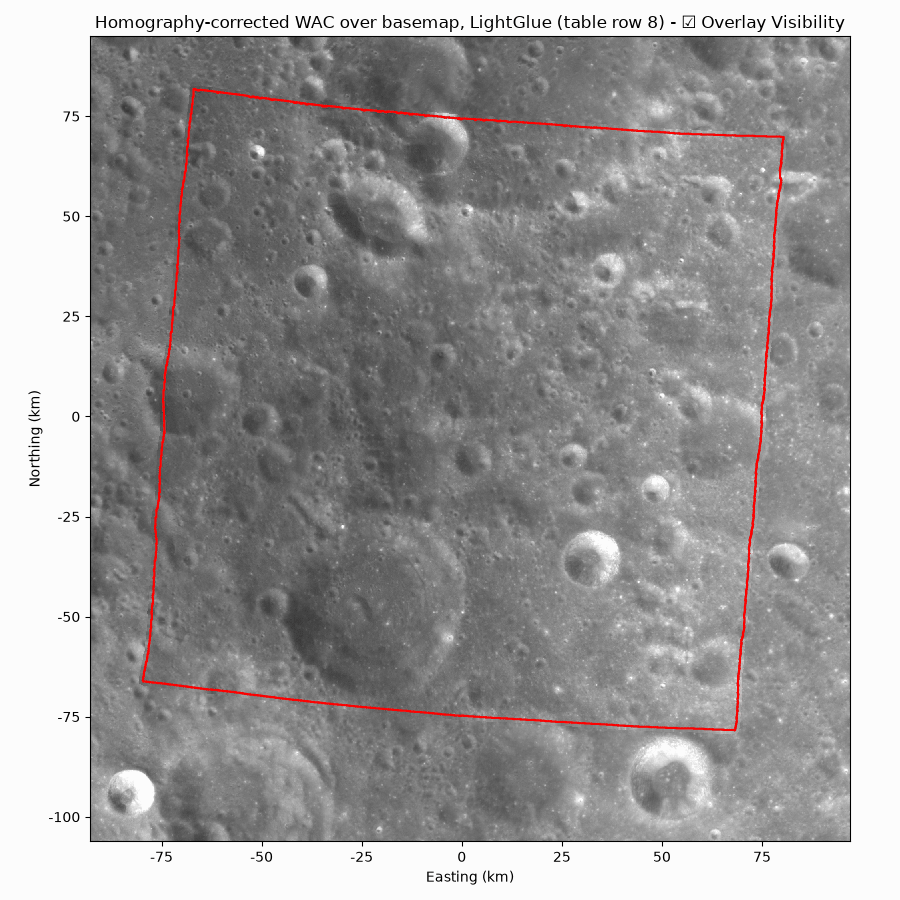

In [15]:
corrected_homography_lg_path = tie_point_matching.apply_homography_correction(
    wac_path, homography_lg, alignment_dir / "wac_corrected_homography_lightglue.tif"
)
plotting.plot_overlay_toggle(
    basemap_path, corrected_homography_lg_path, title="Homography-corrected WAC over basemap, LightGlue (table row 8)"
)

**Table rows 9-10: 3D->2D, LightGlue.** The same 3D pipeline as SIFT's rows 5-6 above, fed
LightGlue's match set instead -- the original headline result (more tie points to work with than
SIFT's), and the fit this notebook's final corrected overlay below is actually built from.

In [16]:
observed_pixels_lg, ground_points_lg_me_m, baseline_norms_lg, baseline_ground_errors_lg_m = resolve_3d_control_points(
    wac_points_map_lg, basemap_points_map_lg, "LightGlue"
)

results.append(
    {
        "row": 9,
        "projection": "3D->2D",
        "matcher": "LightGlue",
        "correction": "uncorrected",
        "dof": 0,
        "n_points": len(observed_pixels_lg),
        "n_kept": len(baseline_ground_errors_lg_m),
        "residual_mean_m": baseline_ground_errors_lg_m.mean(),
        "residual_max_m": baseline_ground_errors_lg_m.max(),
        "residual_mean_px": baseline_norms_lg.mean(),
    }
)

764 real ISIS control points resolved (from 764 LightGlue matches)


Sampled DEM radii: min 1737309m, max 1741608m, mean 1739532m, std 606m (real, varying terrain, not a flat ellipsoid constant -- confirms the DEM is actually in effect)


Baseline (uncorrected), pixel-space (framelet-tiebreak-sensitive): 764/764 points resolved, residual mean 1.56px, max 59.84px


Baseline (uncorrected), ground-space (no ambiguity): 764/764 points resolved, residual mean 277.5m, max 11193.1m


In [17]:
fit_lg, fit_norms_lg, resolved_lg, corrected_crop_lg, fitted_ground_errors_lg_m = fit_and_report_pose_correction(
    ground_points_lg_me_m, observed_pixels_lg
)

results.append(
    {
        "row": 10,
        "projection": "3D->2D",
        "matcher": "LightGlue",
        "correction": "6-DOF pose",
        "dof": 6,
        "n_points": len(observed_pixels_lg),
        "n_kept": len(fitted_ground_errors_lg_m),
        "residual_mean_m": fitted_ground_errors_lg_m.mean(),
        "residual_max_m": fitted_ground_errors_lg_m.max(),
        "residual_mean_px": fit_norms_lg[resolved_lg].mean(),
    }
)

Fit success: True
delta_position_m (MOON_ME): [-2.52280046  0.31731621  1.59240002]
delta_rotation (deg, camera-frame rotation vector): [-0.06110726 -0.06869239 -0.03140833]
Fitted, pixel-space (framelet-tiebreak-sensitive): 764/764 points resolved, residual mean 1.03px, max 59.07px


Fitted, ground-space (no ambiguity): 764/764 points resolved, residual mean 188.4m, max 10997.0m


## Results table

One row per (projection, matcher, correction) combination evaluated -- the original investigation's
combinations plus rows 5-6 (SIFT's 3D->2D pair, added to test an explanation below), reported
systematically instead of scattered prints. `n_points` is the match/control-point set size feeding
that row; `n_kept` is how many actually landed inside the residual stats.

**`residual_mean_px`/`residual_max_m` mean different things for the 2D->2D and 3D->2D rows, and
that difference is itself the finding, not an oversight -- investigated live across several passes,
including two wrong turns worth keeping visible rather than quietly erasing.**

Ruled out along the way: a stale-ellipsoid product sneaking back in (`dem_radii_m` genuinely
varies, hundreds of meters of std, real terrain, not a flat constant); local terrain relief
(residual-vs-elevation correlation across the full point set is ~0 -- an earlier claim that the
worst points sat on the highest terrain didn't survive checking against the full sample); and raw
match-set noise polluting `resolve_control_points` (tested directly via rows 5-6: SIFT's
already-heavily-filtered matches, fed through the same 3D pipeline, still didn't land close to
SIFT's own clean 2D rows -- ruling out match quality as the explanation).

**The methodological gap, caught by a direct question about what `residual_mean_m` even was
for the 3D rows**: it used to be `residual_mean_px * target_gsd_m` -- a unit rescaling of the same
pixel-space quantity, not an independent measurement. And that pixel-space quantity itself
(predicted-vs-observed pixel, via `wac_camera_model`'s own forward projection) is only a legitimate
comparison in the `2D->2D` and `image->ground->image`-round-trip senses -- comparing it against an
independently-resolved `observed_pixels` re-litigates *which* framelet is "right" whenever a
control point's ground location sits in an overlap band (~29% of framelet height, confirmed
live -- see `wac_camera_model.find_framelet_and_project`'s own docstring), which has no
principled answer.

`residual_mean_m`/`residual_max_m` for rows 5-10 are now computed a genuinely different way
(`ground_space_residual_m`): the ground point `observed_pixels` actually corresponds to
(queried directly via `campt`, no framelet search, no ambiguity -- a fixed pixel has exactly
one ground point), compared in meters against the trusted basemap+DEM ground truth. This
never touches `wac_camera_model`'s own tie-break at all. `residual_mean_px` is still reported
alongside it (useful for cross-checking the fit's own optimization target, which does need a pixel-
space loss), but is the ambiguity-sensitive one -- `residual_mean_m` is the one to trust for
comparing the 3D->2D rows against the 2D->2D ones or against each other.

## Two issues, flagged here rather than chased further this session -- one still open

**1. `residual_mean_px` for the 3D->2D rows is now largely redundant with `residual_mean_m`, and
still carries a smaller residual version of the same ambiguity.** `control_network.
resolve_control_points` switched today from `campt` (buggy, see above) to `wac_camera_model.
find_framelet_and_project` for `observed_pixels` too -- so `residual_mean_px`'s `predicted - obs`
now compares two calls to the *same* deterministic function, not a real-vs-buggy-tool mismatch.
But `predicted` and `obs` are for two *different* ground points (trusted vs. WAC-observed); if they
straddle a framelet-overlap tiebreak boundary, the two calls can still legitimately land in
adjacent framelets, producing a discontinuous few-line jump unrelated to real pose error. Whether
to just drop `residual_mean_px` from the 3D->2D rows (keeping it only for 2D->2D, where it's a
direct, uncontaminated unit conversion) is an open question, not yet decided or implemented.

**2. Row 6 (SIFT, 6-DOF pose) no longer shows the regression an earlier version of this notebook
found here.** That earlier run's `delta_position_m` came out around `[566, -397, 1019]` m (~1.2km,
physically implausible), with a ground-space residual of 126m baseline -> 1257m after "correction"
(a ~10x regression) despite looking like an improvement in pixel space -- attributed, not
confirmed, to a position/attitude near-singularity in `fit_pose_correction`'s unconstrained 6-DOF
least-squares on SIFT's smaller point set. Regenerating under current code reproduces none of
that: `delta_position_m` is a plausible few meters, and the ground-space residual is a modest
improvement (183.8m -> 112.9m) in line with every other row in the table. Neither the original
regression nor why it stopped reproducing was investigated further -- the final corrected overlay
below is built from LightGlue's fit (row 10), not SIFT's, unaffected either way.

In [18]:
results_df = pd.DataFrame(results).set_index("row")
results_df

,projection,matcher,correction,dof,n_points,n_kept,residual_mean_m,residual_max_m,residual_mean_px
row,,,,,,,,,
1,2D->2D,SIFT,uncorrected,0,435,435,181.176060,534.733083,0.857399
2,2D->2D,SIFT,similarity,4,435,412,97.432776,333.008624,0.461092
3,2D->2D,SIFT,affine,6,435,413,97.055171,338.097278,0.459305
4,2D->2D,SIFT,homography,8,435,418,103.370341,293.944490,0.489190
5,3D->2D,SIFT,uncorrected,0,435,435,184.225232,541.209647,1.115455
6,3D->2D,SIFT,6-DOF pose,6,435,435,112.072420,529.629952,0.617195
7,2D->2D,LightGlue,uncorrected,0,764,764,275.103997,11178.097952,1.301904
8,2D->2D,LightGlue,homography,8,764,699,143.465955,297.469241,0.678939
9,3D->2D,LightGlue,uncorrected,0,764,764,277.466391,11193.058953,1.561884


## A direct visual before/after: the fitted 6-DOF correction, baked into a corrected overlay

`isis_wac.apply_pose_correction_to_crop` bakes `fit_lg.correction` into a *copy* of the crop cube's
cached `InstrumentPointing` (patching only its single, time-independent `ConstantRotation` matrix
-- see that function's own docstring and docs/external-tools.md's "Patching a cube's cached
pointing via tabledump/csv2table" section for the full mechanism), so ISIS's own already-validated
`cam2map` (`run_cam2map_for_crop`, completely unmodified) picks up the corrected pose
automatically. **Table row 10** (the LightGlue-based fit --
see its own markdown above for why that's the one this notebook's overlay is built from; SIFT's own
row-6 fit isn't separately visualized here).


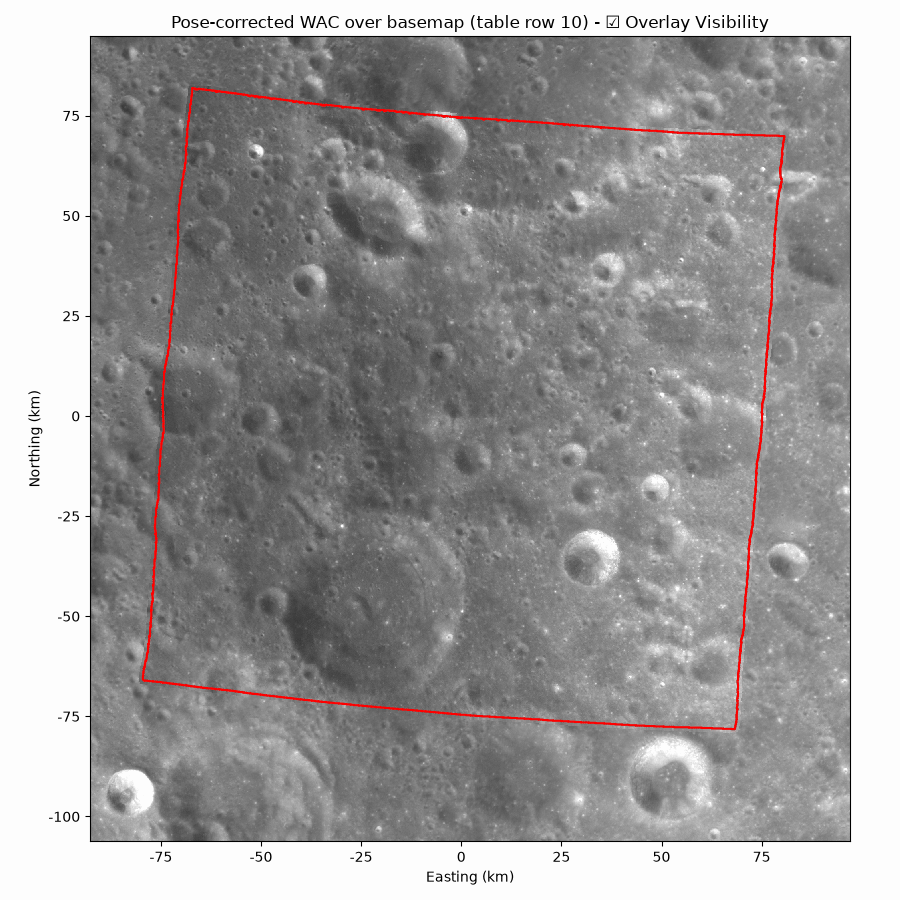

In [19]:
# corrected_crop_lg already exists -- fit_and_report_pose_correction baked it for row 10's own
# ground-space residual above; reused here rather than re-running apply_pose_correction_to_crop.
corrected_cam2map_path = isis_wac.run_cam2map_for_crop(
    corrected_crop_lg, entry.dem_ortho_result, entry.per_image_config
)
plotting.plot_overlay_toggle(
    basemap_path, corrected_cam2map_path, title="Pose-corrected WAC over basemap (table row 10)"
)